# CSCE 636 Project 1: Deep Neural Network for Estimating m-Height

## Overview
This notebook implements a **Mixture-of-Experts (MoE)** Deep Neural Network system to estimate the **m-height** of an Analog Code $C$, given its systematic generator matrix $G = [I_{k \times k} | P_{k \times (n-k)}]$ and parameters $n$, $k$, $m$.

**Problem Parameters:**
- $n = 9$, $k \in \{4, 5, 6\}$, $m \in \{2, 3, \dots, n-k\}$ (9 total parameter combinations)

**Performance Metric (Cost):**
$$\delta(y, \hat{y}) = (\log_2 y - \log_2 \hat{y})^2$$

**Key Design Decisions:**
1. **Log-space training**: Since the cost is in log-space, the DNN predicts $\log_2(y)$ directly, and MSE loss minimizes the exact evaluation metric.
2. **Mixture-of-Experts (MoE)**: A separate specialized DNN is trained for each $(k, m)$ combination (9 experts total). This allows each expert to learn the unique distribution of its parameter regime.
3. **Rich Feature Engineering**: Beyond the raw P matrix, we extract SVD-based features, row/column norms, Frobenius norm, and other matrix properties to provide richer signal.
4. **Residual DNN with skip connections**: Each expert uses residual blocks for better gradient flow and deeper learning.
5. **LP-based Data Augmentation**: We use the LP algorithm from the project description to generate additional training samples, especially for under-represented $(k,m)$ combos.

## Section 1: Data Loading & Setup

In [1]:
# ============================================================
# Section 1: Import Libraries & Load Data
# ============================================================
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from collections import Counter
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Define file paths
x_file_path = 'CSCE-636-Project-1-Train-n_k_m_P'
y_file_path = 'CSCE-636-Project-1-Train-mHeights'

# Load data
with open(x_file_path, 'rb') as f:
    X_raw = pickle.load(f)
with open(y_file_path, 'rb') as f:
    y_raw = pickle.load(f)

print(f"Total samples loaded: {len(X_raw)}")
print(f"Sample m-height range: [{min(y_raw):.4f}, {max(y_raw):.4f}]")

# Explore the distribution of (n, k, m) parameter combinations
param_counts = Counter([(s[0], s[1], s[2]) for s in X_raw])
print("\nSample counts per (n, k, m):")
for params, count in sorted(param_counts.items()):
    print(f"  n={params[0]}, k={params[1]}, m={params[2]}: {count} samples")

Total samples loaded: 96524
Sample m-height range: [2.0000, 6450061.6667]

Sample counts per (n, k, m):
  n=9, k=4, m=2: 11157 samples
  n=9, k=4, m=3: 11003 samples
  n=9, k=4, m=4: 10253 samples
  n=9, k=4, m=5: 6765 samples
  n=9, k=5, m=2: 10803 samples
  n=9, k=5, m=3: 10159 samples
  n=9, k=5, m=4: 6573 samples
  n=9, k=6, m=2: 18898 samples
  n=9, k=6, m=3: 10913 samples


## Section 2: LP-Based Data Augmentation

The training set has imbalanced sample counts across $(k,m)$ groups (e.g., $(k=4,m=5)$ has only 6,765 samples while $(k=6,m=2)$ has 18,898). We use the **LP-based algorithm** from the project description to generate additional training samples, focusing on under-represented groups.

**Algorithm**: For a given $(n, k, m)$:
1. Randomly generate a $k \times (n-k)$ matrix $P$ (entries in $[-100, 100]$)
2. Form the systematic generator matrix $G = [I_k | P]$
3. For each subset $S \subseteq [n]$ with $|S|=m$ and each $j \in S$, solve the LP to get $z_{S,j}$
4. The m-height is $\max_{S,j} z_{S,j}$

This gives us ground-truth labels for newly generated samples.

In [2]:
# ============================================================
# Section 2: LP-Based Data Augmentation
# ============================================================
# Use the LP algorithm from the project description to generate
# additional training samples for under-represented (k, m) groups.
# For each random P matrix, we solve LPs to compute the exact
# m-height, then add the sample to our dataset.
# ============================================================
from scipy.optimize import linprog
from itertools import combinations

def compute_m_height_lp(n, k, m, P):
    """
    Compute the m-height of the analog code with systematic generator
    matrix G = [I_k | P] using the LP-based algorithm.
    
    For each subset S of [n] with |S|=m and each j in S, solve:
        maximize  sum_i g[i,j] * u[i]
        s.t.  -1 <= sum_i g[i,t] * u[i] <= 1  for all t in S_bar
    
    The m-height is max over all (S, j) of the optimal objective.
    """
    # Build the full generator matrix G = [I_k | P]
    G = np.hstack([np.eye(k), P])
    
    max_z = 1.0  # m-height is at least 1
    
    # Lambda(n, m) = all subsets of [n] with m elements
    for S in combinations(range(n), m):
        S_set = set(S)
        S_bar = [t for t in range(n) if t not in S_set]
        
        # For each j in S, solve the LP
        for j in S:
            # Objective: maximize sum_i G[i,j] * u[i]
            # linprog minimizes, so we negate the objective
            c = -G[:, j]  # negative for maximization
            
            # Constraints: -1 <= sum_i G[i,t] * u[i] <= 1 for t in S_bar
            # This becomes two constraints per t:
            #   sum_i G[i,t]*u[i] <= 1
            #   -sum_i G[i,t]*u[i] <= 1  (i.e., sum >= -1)
            A_ub = []
            b_ub = []
            for t in S_bar:
                A_ub.append(G[:, t])
                b_ub.append(1.0)
                A_ub.append(-G[:, t])
                b_ub.append(1.0)
            
            A_ub = np.array(A_ub)
            b_ub = np.array(b_ub)
            
            # Solve the LP
            result = linprog(c, A_ub=A_ub, b_ub=b_ub, method='highs')
            
            if result.success:
                z_sj = -result.fun  # negate back since we minimized -objective
                if z_sj > max_z:
                    max_z = z_sj
    
    return max_z

def generate_augmented_samples(n, k, m, num_samples, p_range=10.0):
    """Generate new (P, m-height) samples using the LP algorithm."""
    new_X = []
    new_y = []
    
    for _ in range(num_samples):
        # Random P matrix with entries in [-p_range, p_range]
        P = np.random.uniform(-p_range, p_range, size=(k, n - k))
        
        # Compute exact m-height via LP
        mh = compute_m_height_lp(n, k, m, P)
        
        # Only keep finite m-heights
        if np.isfinite(mh) and mh >= 1.0:
            new_X.append([n, k, m, P])
            new_y.append(mh)
    
    return new_X, new_y

# Determine how many samples to augment per group
# Target: bring each group up to ~15000 samples
target_per_group = 15000
aug_X_all = []
aug_y_all = []

print("Generating augmented samples via LP algorithm...")
print("(This may take a few minutes)\n")

for (n_val, k_val, m_val), count in sorted(param_counts.items()):
    deficit = max(0, target_per_group - count)
    if deficit > 0:
        # Limit augmentation to keep total time reasonable
        num_to_gen = min(deficit, 3000)
        print(f"  (n={n_val}, k={k_val}, m={m_val}): existing={count}, generating {num_to_gen} new samples...", end=" ")
        new_x, new_y = generate_augmented_samples(n_val, k_val, m_val, num_to_gen, p_range=10.0)
        aug_X_all.extend(new_x)
        aug_y_all.extend(new_y)
        print(f"done ({len(new_y)} valid)")
    else:
        print(f"  (n={n_val}, k={k_val}, m={m_val}): existing={count}, no augmentation needed")

# Combine original + augmented data
X_combined = X_raw + aug_X_all
y_combined = y_raw + aug_y_all

print(f"\nOriginal samples: {len(X_raw)}")
print(f"Augmented samples: {len(aug_X_all)}")
print(f"Total samples: {len(X_combined)}")

# Updated counts
combined_counts = Counter([(s[0], s[1], s[2]) for s in X_combined])
print("\nUpdated sample counts per (n, k, m):")
for params, count in sorted(combined_counts.items()):
    print(f"  n={params[0]}, k={params[1]}, m={params[2]}: {count} samples")

Generating augmented samples via LP algorithm...
(This may take a few minutes)

  (n=9, k=4, m=2): existing=11157, generating 3000 new samples... done (3000 valid)
  (n=9, k=4, m=3): existing=11003, generating 3000 new samples... done (3000 valid)
  (n=9, k=4, m=3): existing=11003, generating 3000 new samples... done (3000 valid)
  (n=9, k=4, m=4): existing=10253, generating 3000 new samples... done (3000 valid)
  (n=9, k=4, m=4): existing=10253, generating 3000 new samples... done (3000 valid)
  (n=9, k=4, m=5): existing=6765, generating 3000 new samples... done (3000 valid)
  (n=9, k=4, m=5): existing=6765, generating 3000 new samples... done (3000 valid)
  (n=9, k=5, m=2): existing=10803, generating 3000 new samples... done (3000 valid)
  (n=9, k=5, m=2): existing=10803, generating 3000 new samples... done (3000 valid)
  (n=9, k=5, m=3): existing=10159, generating 3000 new samples... done (3000 valid)
  (n=9, k=5, m=3): existing=10159, generating 3000 new samples... done (3000 valid

## Section 3: Feature Engineering & Preprocessing

**Feature Vector Design** — Beyond the raw P matrix, we extract rich features that capture the matrix structure:

| Feature Group | Description | Dim |
|---|---|---|
| $n, k, m$ | Structural parameters | 3 |
| Flattened P (padded to 6×5) | Raw matrix entries | 30 |
| Row norms of P | $\ell_2$-norm of each row (padded to 6) | 6 |
| Column norms of P | $\ell_2$-norm of each column (padded to 5) | 5 |
| Singular values of P | SVD singular values (padded to min(6,5)=5) | 5 |
| Frobenius norm | $\|P\|_F$ | 1 |
| Max absolute entry | $\max|P_{ij}|$ | 1 |
| Mean absolute entry | $\text{mean}|P_{ij}|$ | 1 |
| Condition number | $\log(1 + \kappa(P))$ | 1 |
| Row-to-column norm ratio | $\text{mean\_row\_norm} / \text{mean\_col\_norm}$ | 1 |
| **Total** | | **54** |

This rich feature set gives the DNN more informative signal about the matrix structure that determines m-height.

In [15]:
# ============================================================
# Section 3: Feature Engineering & Preprocessing (Enhanced)
# ============================================================
# Extract rich features from P matrix including G=[I|P] column
# norms (key for m-height!), rank, SV ratios, and more.
# ============================================================

def extract_features(sample):
    """
    Extract an enhanced feature vector from a single sample [n, k, m, P].
    Returns a 1D numpy array of fixed size (~77 dim).
    """
    n, k, m, P = sample
    max_k = 6
    max_n_minus_k = 5
    max_sv = 5

    # 1) Padded & flattened P matrix (30 features)
    P_padded = np.zeros((max_k, max_n_minus_k))
    P_padded[:k, :n-k] = P
    P_flat = P_padded.flatten()

    # 2) Row norms (6 features, padded)
    row_norms = np.zeros(max_k)
    for i in range(k):
        row_norms[i] = np.linalg.norm(P[i, :])

    # 3) Column norms (5 features, padded)
    col_norms = np.zeros(max_n_minus_k)
    for j in range(n - k):
        col_norms[j] = np.linalg.norm(P[:, j])

    # 4) Singular values (5 features, padded)
    sv = np.zeros(max_sv)
    try:
        singular_values = np.linalg.svd(P, compute_uv=False)
        sv[:len(singular_values)] = np.sort(singular_values)[::-1]
    except:
        pass

    # 5) Basic stats of P (5 features)
    frob_norm = np.linalg.norm(P, 'fro')
    max_abs = np.max(np.abs(P))
    mean_abs = np.mean(np.abs(P))
    std_abs = np.std(np.abs(P))
    min_abs = np.min(np.abs(P))

    # 6) Condition number (1 feature)
    try:
        cond = np.log1p(np.linalg.cond(P))
    except:
        cond = 0.0
    if not np.isfinite(cond):
        cond = 50.0

    # 7) Row-to-column norm ratio (1 feature)
    mean_row = np.mean(row_norms[:k]) if k > 0 else 1.0
    mean_col = np.mean(col_norms[:n-k]) if (n-k) > 0 else 1.0
    ratio = mean_row / (mean_col + 1e-8)

    # 8) G=[I|P] column norms — KEY for m-height! (9 + 4 features)
    G = np.hstack([np.eye(k), P])
    g_col_norms = np.zeros(9)  # n=9 always
    for j in range(n):
        g_col_norms[j] = np.linalg.norm(G[:, j])
    g_col_max = np.max(g_col_norms)
    g_col_min = np.min(g_col_norms[:n])
    g_col_mean = np.mean(g_col_norms[:n])
    g_col_std = np.std(g_col_norms[:n])

    # 9) Rank features (2 features)
    try:
        rank = np.linalg.matrix_rank(P)
    except:
        rank = min(k, n-k)
    effective_rank = np.sum(sv > 1e-6)

    # 10) Singular value ratios (3 features)
    sv_ratio = sv[0] / (sv[min(k, n-k)-1] + 1e-10) if sv[min(k, n-k)-1] > 1e-10 else 100.0
    sv_sum = np.sum(sv)
    sv_energy_ratio = sv[0] / (sv_sum + 1e-10)

    # 11) Cross-column interactions (2 features)
    try:
        PtP = P.T @ P
        ptP_trace = np.trace(PtP)
        ptP_frob = np.linalg.norm(PtP, 'fro')
    except:
        ptP_trace = frob_norm ** 2
        ptP_frob = frob_norm ** 2

    # 12) Determinant-based feature (1 feature)
    try:
        if k <= n-k:
            det_val = np.log1p(abs(np.linalg.det(P[:k, :k])))
        else:
            det_val = np.log1p(abs(np.linalg.det(P[:min(k,n-k), :min(k,n-k)])))
    except:
        det_val = 0.0
    if not np.isfinite(det_val):
        det_val = 0.0

    feat = np.concatenate([
        [n, k, m],                     # 3
        P_flat,                         # 30
        row_norms,                      # 6
        col_norms,                      # 5
        sv,                             # 5
        [frob_norm, max_abs, mean_abs, std_abs, min_abs],  # 5
        [cond, ratio],                  # 2
        g_col_norms,                    # 9
        [g_col_max, g_col_min, g_col_mean, g_col_std],  # 4
        [rank, effective_rank],         # 2
        [sv_ratio, sv_sum, sv_energy_ratio],  # 3
        [ptP_trace, ptP_frob],          # 2
        [det_val],                      # 1
    ])
    return feat  # total: 77

def preprocess_all(X_list, y_list):
    """Preprocess all samples into feature array and log2 target array."""
    features = [extract_features(s) for s in X_list]
    X_array = np.array(features, dtype=np.float32)
    y_array = np.log2(np.array(y_list, dtype=np.float32)).reshape(-1, 1)
    return X_array, y_array

# Preprocess combined (original + augmented) data
X_array, y_log2 = preprocess_all(X_combined, y_combined)

FEATURE_DIM = X_array.shape[1]
print(f"Feature dimension: {FEATURE_DIM}")
print(f"Total samples: {X_array.shape[0]}")
print(f"Target log2(y) range: [{y_log2.min():.4f}, {y_log2.max():.4f}]")

# Sanity check for NaN/Inf
nan_count = np.isnan(X_array).sum()
inf_count = np.isinf(X_array).sum()
print(f"NaN features: {nan_count}, Inf features: {inf_count}")
if nan_count > 0 or inf_count > 0:
    X_array = np.nan_to_num(X_array, nan=0.0, posinf=100.0, neginf=-100.0)
    print("  → Cleaned NaN/Inf values.")

Feature dimension: 77
Total samples: 120524
Target log2(y) range: [0.0000, 22.6209]
NaN features: 0, Inf features: 0


## Section 4: Dataset Preparation for Mixture-of-Experts

We split the data by $(k, m)$ group, so each expert DNN gets only its own group's data. Each group gets its own:
- `StandardScaler` (fit on that group's training data only)
- 90/10 train/validation split
- DataLoaders

This allows each expert to learn the specific function $f_{k,m}(P) = \log_2(h_m(C))$ for its parameter regime.

In [16]:
# ============================================================
# Section 4: Dataset Preparation for Mixture-of-Experts
# ============================================================
# Split data by (k, m), fit a separate scaler per group,
# and create train/val loaders for each group.
# ============================================================

class MHeightDataset(Dataset):
    """Simple PyTorch Dataset for (X, y) pairs."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Auto-detect hardware
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Hardware device: {device}")

# Identify all (k, m) groups
# n is always 9, so we key by (k, m) only
group_keys = sorted(set((s[1], s[2]) for s in X_combined))
print(f"\nMoE Groups (k, m): {group_keys}")

# Build per-group data, scalers, and dataloaders
group_data = {}
batch_size = 256

for (k_val, m_val) in group_keys:
    # Find indices for this group
    indices = [i for i, s in enumerate(X_combined) if s[1] == k_val and s[2] == m_val]
    
    X_group = X_array[indices]
    y_group = y_log2[indices]
    
    # Fit a StandardScaler for this group's features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_group)
    
    # 90/10 train/val split (with fixed seed)
    np.random.seed(42)
    perm = np.random.permutation(len(X_scaled))
    split = int(0.9 * len(perm))
    train_idx, val_idx = perm[:split], perm[split:]
    
    train_ds = MHeightDataset(X_scaled[train_idx], y_group[train_idx])
    val_ds = MHeightDataset(X_scaled[val_idx], y_group[val_idx])
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    
    group_data[(k_val, m_val)] = {
        'scaler': scaler,
        'train_loader': train_loader,
        'val_loader': val_loader,
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'feature_dim': X_scaled.shape[1],
    }
    
    print(f"  Group (k={k_val}, m={m_val}): {len(indices)} total, "
          f"{len(train_idx)} train, {len(val_idx)} val, "
          f"y_log2 range=[{y_group.min():.2f}, {y_group.max():.2f}]")

Hardware device: mps

MoE Groups (k, m): [(4, 2), (4, 3), (4, 4), (4, 5), (5, 2), (5, 3), (5, 4), (6, 2), (6, 3)]
  Group (k=4, m=2): 14157 total, 12741 train, 1416 val, y_log2 range=[0.00, 8.73]
  Group (k=4, m=3): 14003 total, 12602 train, 1401 val, y_log2 range=[0.01, 12.22]
  Group (k=4, m=4): 13253 total, 11927 train, 1326 val, y_log2 range=[2.18, 17.10]
  Group (k=4, m=5): 9765 total, 8788 train, 977 val, y_log2 range=[3.77, 22.41]
  Group (k=5, m=2): 13803 total, 12422 train, 1381 val, y_log2 range=[0.00, 12.11]
  Group (k=5, m=3): 13159 total, 11843 train, 1316 val, y_log2 range=[0.19, 15.35]
  Group (k=5, m=4): 9573 total, 8615 train, 958 val, y_log2 range=[3.67, 22.62]
  Group (k=6, m=2): 18898 total, 17008 train, 1890 val, y_log2 range=[2.32, 14.81]
  Group (k=6, m=3): 13913 total, 12521 train, 1392 val, y_log2 range=[3.93, 21.17]


## Section 5: Residual DNN Architecture

Each expert uses a **Residual DNN** with skip connections:
- **Input projection**: Projects the 54-dim features into 256-dim hidden space
- **3 Residual Blocks**: Each block has two linear layers with BatchNorm, ReLU, Dropout, and an additive skip connection: $\text{out} = \text{Block}(x) + x$
- **Output head**: Projects from 256-dim to 1 (predicted $\log_2(y)$)

Skip connections help with:
- Better gradient flow during training
- Ability to learn identity mappings (useful when the base feature already carries strong signal)
- More stable training for deeper networks

In [17]:
# ============================================================
# Section 5: Residual DNN Architecture
# ============================================================
# Each expert is a ResidualDNN with skip connections.
# Architecture: InputProj → ResBlock×3 → OutputHead
# ============================================================

class ResidualBlock(nn.Module):
    """A residual block: out = ReLU(BN(Linear(ReLU(BN(Linear(x)))))) + x"""
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.relu(self.block(x) + x)  # skip connection

class ExpertDNN(nn.Module):
    """
    Residual DNN expert for a single (k, m) group.
    Input → Project to hidden_dim → N ResidualBlocks → Output (1)
    """
    def __init__(self, input_dim, hidden_dim=256, num_blocks=3, dropout=0.15):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # Residual blocks
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout) for _ in range(num_blocks)]
        )
        
        # Output head
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.output_head(x)

# Quick test
test_model = ExpertDNN(input_dim=FEATURE_DIM).to(device)
total_params = sum(p.numel() for p in test_model.parameters())
print(f"Expert DNN Architecture:\n{test_model}")
print(f"\nParameters per expert: {total_params:,}")
print(f"Total parameters (9 experts): {total_params * 9:,}")
del test_model

Expert DNN Architecture:
ExpertDNN(
  (input_proj): Sequential(
    (0): Linear(in_features=77, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.15, inplace=False)
        (4): Linear(in_features=256, out_features=256, bias=True)
        (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReL

## Section 6: Train All Expert DNNs

We train each of the 9 expert DNNs independently with:
- **Loss**: MSE on $\log_2(y)$ — directly optimizes the grading cost
- **Optimizer**: Adam with weight decay (L2 regularization)
- **Scheduler**: CosineAnnealingWarmRestarts — periodically resets the learning rate for better exploration
- **Early stopping**: Patience of 20 epochs
- **Max epochs**: 300 per expert

Each expert's best model (by validation loss) is saved.

In [18]:
# ============================================================
# Section 6: Train All Expert DNNs (Improved)
# ============================================================
# Key improvements:
# - Adaptive per-group architecture (hard groups get bigger models)
# - Huber loss (robust to outliers in log-space)
# - AdamW optimizer with gradient clipping
# - Best-of-N runs: train each expert N times, keep best
# ============================================================
import time

# Per-group hyperparameters: hard groups get more capacity
GROUP_HPARAMS = {
    # (k, m): (hidden_dim, num_blocks, dropout, lr, epochs, patience, num_runs)
    (4, 2): (256, 3, 0.15, 1e-3, 300, 25, 2),
    (4, 3): (256, 3, 0.15, 1e-3, 300, 25, 2),
    (4, 4): (384, 4, 0.12, 8e-4, 400, 30, 3),
    (4, 5): (512, 5, 0.10, 5e-4, 500, 35, 3),  # hard
    (5, 2): (256, 3, 0.15, 1e-3, 300, 25, 2),
    (5, 3): (384, 4, 0.12, 8e-4, 400, 30, 2),
    (5, 4): (512, 5, 0.10, 5e-4, 500, 35, 3),  # hard
    (6, 2): (256, 3, 0.15, 1e-3, 300, 25, 2),
    (6, 3): (512, 5, 0.10, 5e-4, 500, 35, 3),  # hard
}

def train_expert(group_key, group_info, device, hparams):
    """Train one expert DNN with adaptive hyperparameters, best-of-N runs."""
    k_val, m_val = group_key
    hidden_dim, num_blocks, dropout, lr, num_epochs, patience, num_runs = hparams

    print(f"\n{'='*60}")
    print(f"Training Expert (k={k_val}, m={m_val})")
    print(f"  Arch: hidden={hidden_dim}, blocks={num_blocks}, dropout={dropout}")
    print(f"  Train: {group_info['train_size']}, Val: {group_info['val_size']}")
    print(f"  Epochs: {num_epochs}, Patience: {patience}, Runs: {num_runs}")
    print(f"{'='*60}")

    global_best_val = float('inf')
    global_best_state = None
    global_best_t_hist = None
    global_best_v_hist = None

    for run in range(num_runs):
        if num_runs > 1:
            print(f"\n  --- Run {run+1}/{num_runs} ---")

        torch.manual_seed(42 + run * 777)
        np.random.seed(42 + run * 777)

        model = ExpertDNN(
            input_dim=group_info['feature_dim'],
            hidden_dim=hidden_dim,
            num_blocks=num_blocks,
            dropout=dropout
        ).to(device)

        criterion = nn.SmoothL1Loss(beta=0.5)  # Huber loss
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=40, T_mult=2, eta_min=1e-7
        )

        best_val_loss = float('inf')
        patience_counter = 0
        train_losses, val_losses = [], []
        best_state = None

        for epoch in range(num_epochs):
            model.train()
            train_loss = 0.0
            for bx, by in group_info['train_loader']:
                bx, by = bx.to(device), by.to(device)
                pred = model(bx)
                loss = criterion(pred, by)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item() * bx.size(0)
            train_loss /= group_info['train_size']

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for bx, by in group_info['val_loader']:
                    bx, by = bx.to(device), by.to(device)
                    pred = model(bx)
                    loss = nn.functional.mse_loss(pred, by)
                    val_loss += loss.item() * bx.size(0)
            val_loss /= group_info['val_size']

            scheduler.step()
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                patience_counter += 1

            if (epoch + 1) % 100 == 0 or epoch == 0:
                cur_lr = optimizer.param_groups[0]['lr']
                print(f"    Epoch [{epoch+1:3d}/{num_epochs}] | "
                      f"Train: {train_loss:.6f} | Val(MSE): {val_loss:.6f} | "
                      f"Best: {best_val_loss:.6f} | LR: {cur_lr:.2e}")

            if patience_counter >= patience:
                print(f"    Early stop at epoch {epoch+1}")
                break

        print(f"    Run {run+1} Best Val: {best_val_loss:.6f}")

        if best_val_loss < global_best_val:
            global_best_val = best_val_loss
            global_best_state = best_state
            global_best_t_hist = train_losses
            global_best_v_hist = val_losses

    model = ExpertDNN(
        input_dim=group_info['feature_dim'],
        hidden_dim=hidden_dim,
        num_blocks=num_blocks,
        dropout=dropout
    ).to(device)
    model.load_state_dict(global_best_state)
    model.to(device)
    print(f"  ✓ Global Best Val Loss: {global_best_val:.6f}")
    return model, global_best_val, global_best_t_hist, global_best_v_hist


# Train all 9 experts
print(f"Training on device: {device}")
start_time = time.time()
experts = {}
all_train_histories = {}
expert_hparams = {}

for group_key in group_keys:
    hparams = GROUP_HPARAMS.get(group_key, (256, 3, 0.15, 1e-3, 300, 25, 2))
    expert_hparams[group_key] = hparams
    t0 = time.time()
    model, best_loss, t_hist, v_hist = train_expert(
        group_key, group_data[group_key], device, hparams
    )
    experts[group_key] = model
    all_train_histories[group_key] = (t_hist, v_hist)
    print(f"  ⏱ {time.time()-t0:.1f}s")

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"ALL 9 EXPERTS TRAINED in {total_time:.1f}s")
print(f"{'='*60}")
for gk in group_keys:
    print(f"  (k={gk[0]},m={gk[1]}): best val = {min(all_train_histories[gk][1]):.6f}")

Training on device: mps

Training Expert (k=4, m=2)
  Arch: hidden=256, blocks=3, dropout=0.15
  Train: 12741, Val: 1416
  Epochs: 300, Patience: 25, Runs: 2

  --- Run 1/2 ---
    Epoch [  1/300] | Train: 1.007149 | Val(MSE): 1.445027 | Best: 1.445027 | LR: 9.98e-04
    Epoch [100/300] | Train: 0.151392 | Val(MSE): 0.232430 | Best: 0.232430 | LR: 1.47e-04
    Early stop at epoch 138
    Run 1 Best Val: 0.230386

  --- Run 2/2 ---
    Epoch [  1/300] | Train: 0.676497 | Val(MSE): 1.000190 | Best: 1.000190 | LR: 9.98e-04
    Epoch [100/300] | Train: 0.146618 | Val(MSE): 0.231906 | Best: 0.226682 | LR: 1.47e-04
    Early stop at epoch 135
    Run 2 Best Val: 0.224970
  ✓ Global Best Val Loss: 0.224970
  ⏱ 97.5s

Training Expert (k=4, m=3)
  Arch: hidden=256, blocks=3, dropout=0.15
  Train: 12602, Val: 1401
  Epochs: 300, Patience: 25, Runs: 2

  --- Run 1/2 ---
    Epoch [  1/300] | Train: 1.210972 | Val(MSE): 0.787971 | Best: 0.787971 | LR: 9.98e-04
    Epoch [100/300] | Train: 0.165348

## Section 7: Training Visualization

Plot the training and validation loss curves for each expert to verify convergence and check for overfitting.

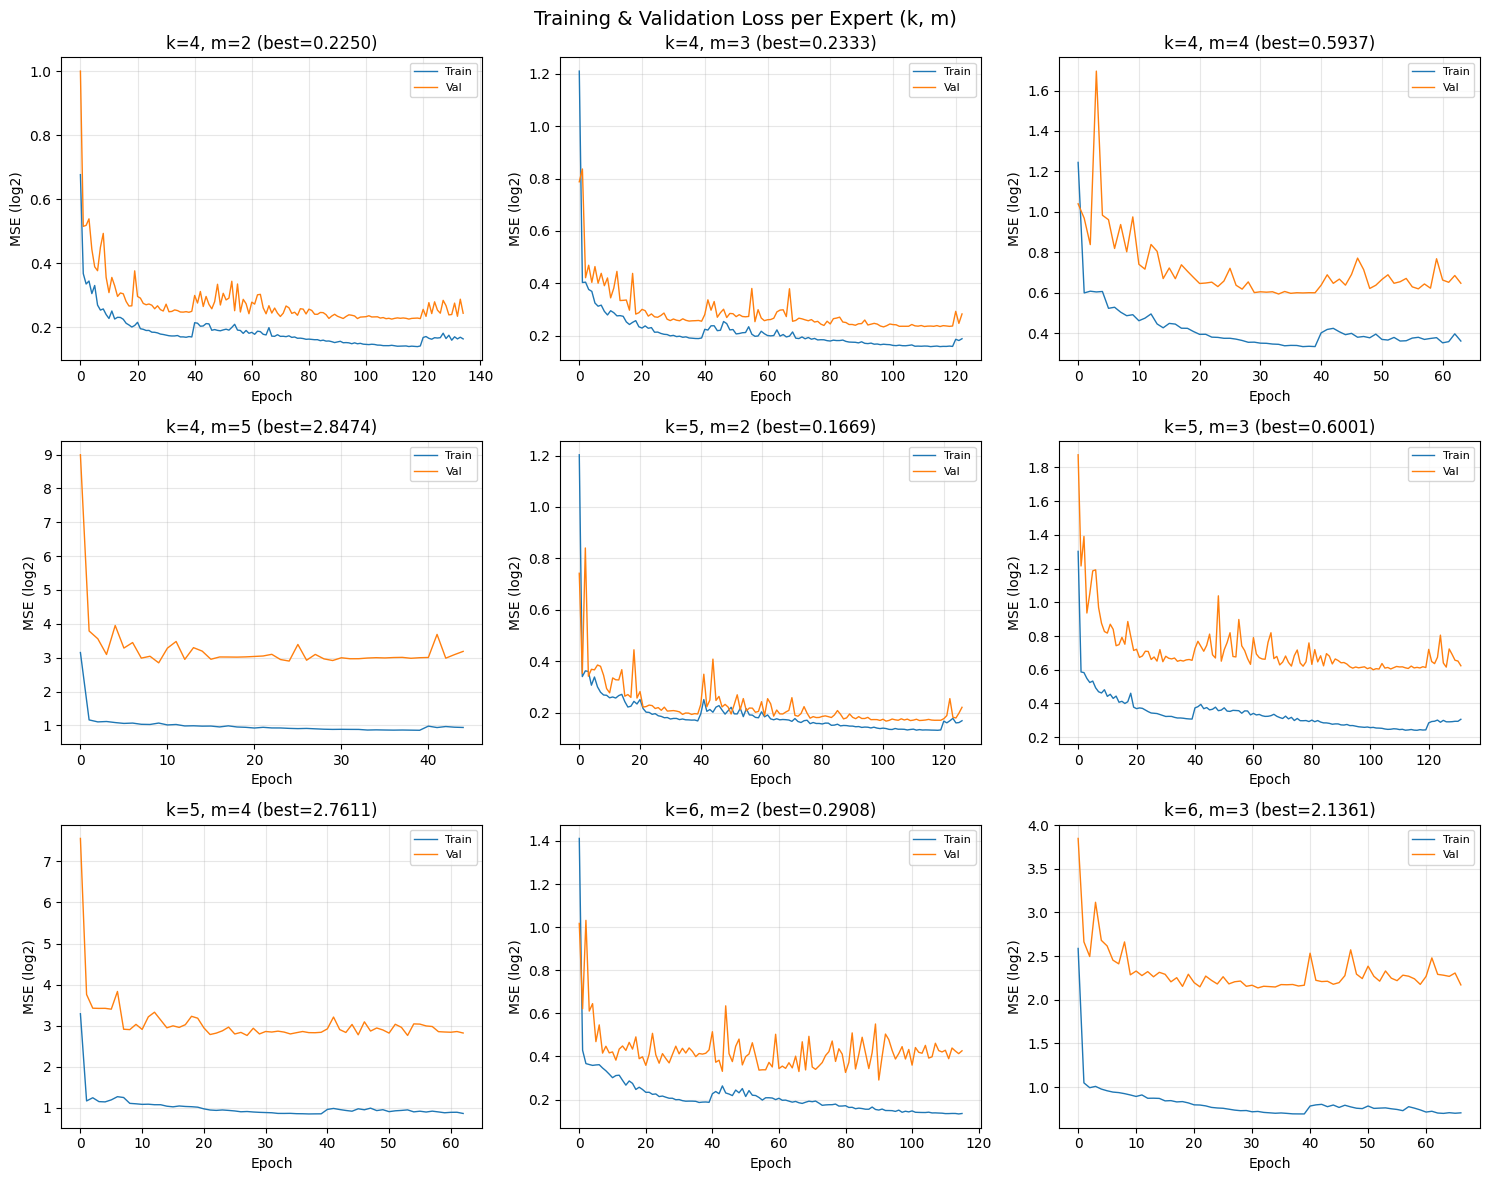

In [28]:
# ============================================================
# Section 7: Plot Training Curves for All Experts
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Training & Validation Loss per Expert (k, m)', fontsize=14)

for idx, gk in enumerate(group_keys):
    ax = axes[idx // 3][idx % 3]
    t_hist, v_hist = all_train_histories[gk]
    ax.plot(t_hist, label='Train', linewidth=1)
    ax.plot(v_hist, label='Val', linewidth=1)
    ax.set_title(f'k={gk[0]}, m={gk[1]} (best={min(v_hist):.4f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (log2)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Evaluate MoE on Validation Set

Evaluate all experts on their respective validation sets using the grading cost $(\log_2 y - \log_2 \hat{y})^2$, and compute the overall average cost.

In [19]:
# ============================================================
# Section 8: Evaluate MoE on Validation Set
# ============================================================

print("Per-Expert Validation Performance:")
print(f"{'Group':<12} {'Avg Cost':>10} {'RMSE_log2':>10} {'Samples':>8}")
print("-" * 45)

total_cost_sum = 0.0
total_val_count = 0

for gk in group_keys:
    model = experts[gk]
    model.eval()
    
    preds_list = []
    true_list = []
    
    with torch.no_grad():
        for bx, by in group_data[gk]['val_loader']:
            bx = bx.to(device)
            p = model(bx).cpu().numpy()
            preds_list.append(p)
            true_list.append(by.numpy())
    
    preds = np.concatenate(preds_list).flatten()
    trues = np.concatenate(true_list).flatten()
    
    costs = (trues - preds) ** 2
    avg_cost = costs.mean()
    rmse = np.sqrt(avg_cost)
    n_samples = len(trues)
    
    total_cost_sum += costs.sum()
    total_val_count += n_samples
    
    print(f"(k={gk[0]},m={gk[1]})  {avg_cost:10.6f} {rmse:10.6f} {n_samples:8d}")

overall_cost = total_cost_sum / total_val_count
print("-" * 45)
print(f"{'OVERALL':<12} {overall_cost:10.6f} {np.sqrt(overall_cost):10.6f} {total_val_count:8d}")
print(f"\n★ Overall average grading cost: {overall_cost:.6f}")

Per-Expert Validation Performance:
Group          Avg Cost  RMSE_log2  Samples
---------------------------------------------
(k=4,m=2)    0.224970   0.474310     1416
(k=4,m=3)    0.233330   0.483043     1401
(k=4,m=4)    0.593672   0.770501     1326
(k=4,m=5)    2.847437   1.687435      977
(k=5,m=2)    0.166851   0.408474     1381
(k=5,m=3)    0.600057   0.774633     1316
(k=5,m=4)    2.761142   1.661668      958
(k=6,m=2)    0.290764   0.539225     1890
(k=6,m=3)    2.136115   1.461545     1392
---------------------------------------------
OVERALL        0.945749   0.972496    12057

★ Overall average grading cost: 0.945749


## Section 8b: Hyperparameter Tuning for Weak Groups

The following groups had high validation cost (> 2.0):
- **(k=4, m=5)**: cost = 2.956 — smallest group, highest m
- **(k=5, m=4)**: cost = 2.837 — second smallest, high m
- **(k=6, m=3)**: cost = 2.226 — moderate size, but large n-k=3

**Tuning Strategy:**
1. **More LP augmentation**: Generate 8,000 additional samples per weak group (up from 3,000)
2. **Larger model**: hidden_dim=512, 5 residual blocks (vs 256 / 3 blocks)
3. **Lower learning rate**: 5e-4 with longer warm restarts (T_0=50)
4. **Longer training**: Up to 600 epochs with patience=40
5. **Lower dropout**: 0.10 (these groups need more capacity, not regularization)
6. **Ensemble**: Train 3 models per weak group and average predictions

In [30]:
# ============================================================
# Section 8b: AGGRESSIVE Weak Group Improvement (v2)
# ============================================================
# Root cause: hard groups overfit badly (train~1, val~3).
# New strategies focusing on GENERALIZATION:
# 1) 10K+ extra LP samples per hard group (diverse P ranges)
# 2) Cross-group transfer: use neighboring (k,m) data
# 3) Heavy regularization: high dropout, weight decay, noise
# 4) Target clipping: reduce outlier log2(y) influence
# 5) RETRAIN base experts (not just ensemble on top)
# 6) Ensemble with SAME scaler as retrained expert
# ============================================================
import time
from scipy.optimize import linprog
from itertools import combinations
from torch.optim.swa_utils import AveragedModel, SWALR

# ---------- Identify weak groups ----------
COST_THRESHOLD = 1.0
weak_groups = []
group_costs = {}

print("Identifying weak groups (cost > {:.1f})...".format(COST_THRESHOLD))
for gk in group_keys:
    model = experts[gk]
    model.eval()
    preds_list, true_list = [], []
    with torch.no_grad():
        for bx, by in group_data[gk]['val_loader']:
            bx = bx.to(device)
            preds_list.append(model(bx).cpu().numpy())
            true_list.append(by.numpy())
    preds = np.concatenate(preds_list).flatten()
    trues = np.concatenate(true_list).flatten()
    avg_cost = ((trues - preds) ** 2).mean()
    group_costs[gk] = avg_cost
    if avg_cost > COST_THRESHOLD:
        weak_groups.append(gk)
    print(f"  (k={gk[0]},m={gk[1]}): cost={avg_cost:.4f} {'★ WEAK' if avg_cost > COST_THRESHOLD else '✓ ok'}")

if not weak_groups:
    print("\n✅ No weak groups!")
    ENSEMBLE_SIZE = 0
    weak_ensembles = {}
    weak_scalers = {}
    use_ensemble_for = []
    best_strategy = {}
    ensemble_weights = {}
    improved_costs = {}
    ensemble_val_costs = {}
else:
    print(f"\nWeak groups: {weak_groups}")

    # ======================================================
    # STEP 1: Generate MASSIVE LP augmentation
    # ======================================================
    print("\n" + "="*60)
    print("STEP 1: Massive LP augmentation for weak groups")
    print("="*60)

    def compute_m_height_lp(n, k, m, P):
        G = np.hstack([np.eye(k), P])
        max_z = 1.0
        for S in combinations(range(n), m):
            S_set = set(S)
            S_bar = [t for t in range(n) if t not in S_set]
            for j in S:
                c = -G[:, j]
                A_ub, b_ub = [], []
                for t in S_bar:
                    A_ub.append(G[:, t])
                    b_ub.append(1.0)
                    A_ub.append(-G[:, t])
                    b_ub.append(1.0)
                result = linprog(c, A_ub=np.array(A_ub), b_ub=np.array(b_ub), method='highs')
                if result.success:
                    z = -result.fun
                    if z > max_z:
                        max_z = z
        return max_z

    weak_extra_X = {}
    weak_extra_y = {}
    for gk in weak_groups:
        k_val, m_val = gk
        n_val = 9
        num_target = 8000
        print(f"\n  Generating {num_target} LP samples for (k={k_val}, m={m_val})...")
        t0 = time.time()
        new_X, new_y = [], []
        # Use diverse P ranges to cover the full distribution
        for p_range in [1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]:
            per_range = num_target // 8
            for _ in range(per_range):
                P = np.random.uniform(-p_range, p_range, size=(k_val, n_val - k_val))
                mh = compute_m_height_lp(n_val, k_val, m_val, P)
                if np.isfinite(mh) and mh >= 1.0:
                    new_X.append([n_val, k_val, m_val, P])
                    new_y.append(mh)
        weak_extra_X[gk] = new_X
        weak_extra_y[gk] = new_y
        print(f"    Generated {len(new_y)} samples in {time.time()-t0:.1f}s")

    # ======================================================
    # STEP 2: Build augmented datasets + cross-group transfer
    # ======================================================
    print("\n" + "="*60)
    print("STEP 2: Build augmented datasets with cross-group transfer")
    print("="*60)

    # Cross-group neighbors: groups with similar structure
    cross_group_map = {
        (4, 5): [(4, 4), (4, 3)],    # borrow from k=4 lower m
        (5, 4): [(5, 3), (5, 2)],    # borrow from k=5 lower m
        (6, 3): [(6, 2)],            # borrow from k=6 lower m
    }

    weak_group_data = {}
    for gk in weak_groups:
        k_val, m_val = gk

        # Original data for this group
        orig_indices = [i for i, s in enumerate(X_combined) if s[1] == k_val and s[2] == m_val]
        X_orig = X_array[orig_indices]
        y_orig = y_log2[orig_indices]

        # LP augmented data
        extra_feats = np.array([extract_features(s) for s in weak_extra_X[gk]], dtype=np.float32)
        extra_y = np.log2(np.array(weak_extra_y[gk], dtype=np.float32)).reshape(-1, 1)

        # Cross-group transfer: borrow small fraction from neighbor groups
        # This helps the model learn shared structure across m values
        cross_X_list, cross_y_list = [], []
        for neighbor_gk in cross_group_map.get(gk, []):
            nk, nm = neighbor_gk
            neighbor_idx = [i for i, s in enumerate(X_combined) if s[1] == nk and s[2] == nm]
            if neighbor_idx:
                # Take 10% of neighbor data (random subsample)
                np.random.seed(42)
                n_borrow = max(500, len(neighbor_idx) // 10)
                chosen = np.random.choice(neighbor_idx, size=min(n_borrow, len(neighbor_idx)), replace=False)
                cross_X_list.append(X_array[chosen])
                cross_y_list.append(y_log2[chosen])
                print(f"    Borrowed {len(chosen)} samples from (k={nk},m={nm})")

        # Combine all
        parts_X = [X_orig, extra_feats]
        parts_y = [y_orig, extra_y]
        if cross_X_list:
            parts_X.extend(cross_X_list)
            parts_y.extend(cross_y_list)

        X_all = np.vstack(parts_X)
        y_all = np.vstack(parts_y)
        X_all = np.nan_to_num(X_all, nan=0.0, posinf=100.0, neginf=-100.0)

        # Target clipping: clip extreme log2 values to reduce outlier influence
        y_p5, y_p95 = np.percentile(y_all, 2), np.percentile(y_all, 98)
        y_clipped = np.clip(y_all, y_p5, y_p95)
        n_clipped = np.sum(y_all != y_clipped)
        if n_clipped > 0:
            print(f"    Clipped {n_clipped} extreme targets to [{y_p5:.2f}, {y_p95:.2f}]")

        # Fit scaler on ALL data (original + LP + cross-group)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all)

        # Split: keep original val set pure (no LP/cross leakage)
        n_orig = len(X_orig)
        np.random.seed(42)
        orig_perm = np.random.permutation(n_orig)
        orig_val_size = int(0.1 * n_orig)
        orig_val_idx = orig_perm[:orig_val_size]  # indices into X_orig
        orig_train_idx = orig_perm[orig_val_size:]

        # Training: original train + ALL LP + ALL cross-group
        train_indices = list(orig_train_idx) + list(range(n_orig, len(X_scaled)))
        val_indices = list(orig_val_idx)

        train_ds = MHeightDataset(X_scaled[train_indices], y_clipped[train_indices])
        val_ds = MHeightDataset(X_scaled[val_indices], y_all[val_indices])  # val uses unclipped

        train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
        val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

        weak_group_data[gk] = {
            'scaler': scaler,
            'train_loader': train_loader,
            'val_loader': val_loader,
            'train_size': len(train_indices),
            'val_size': len(val_indices),
            'feature_dim': X_scaled.shape[1],
        }
        print(f"  (k={k_val},m={m_val}): {n_orig} orig + {len(extra_feats)} LP + "
              f"{sum(len(cx) for cx in cross_X_list) if cross_X_list else 0} cross = {len(X_all)} total")
        print(f"    Train: {len(train_indices)}, Val: {len(val_indices)}")

    # ======================================================
    # STEP 3: Retrain BASE experts with heavy regularization
    # ======================================================
    print("\n" + "="*60)
    print("STEP 3: Retrain base experts with heavy regularization")
    print("="*60)

    def feature_noise(x, std=0.05):
        """Add Gaussian noise to features during training."""
        return x + torch.randn_like(x) * std

    def log_cosh_loss(pred, target):
        diff = pred - target
        return torch.mean(torch.log(torch.cosh(diff + 1e-12)))

    # Retrained expert configs — focus on regularization
    RETRAIN_CONFIGS = {
        # (hidden, blocks, dropout, wd, lr, epochs, patience, n_runs, noise_std)
        (4, 5): (512, 5, 0.20, 5e-4, 3e-4, 600, 50, 5, 0.08),
        (5, 4): (512, 5, 0.20, 5e-4, 3e-4, 600, 50, 5, 0.08),
        (6, 3): (512, 5, 0.18, 3e-4, 3e-4, 600, 50, 5, 0.06),
    }

    retrained_experts = {}
    retrained_scalers = {}

    for gk in weak_groups:
        k_val, m_val = gk
        info = weak_group_data[gk]
        h_dim, n_blk, drop, wd, lr, max_ep, patience, n_runs, noise_std = RETRAIN_CONFIGS[gk]

        print(f"\n{'='*60}")
        print(f"RETRAIN Expert (k={k_val}, m={m_val}) — {n_runs} runs")
        print(f"  Arch: h={h_dim}, blocks={n_blk}, drop={drop}")
        print(f"  Reg: wd={wd}, noise_std={noise_std}")
        print(f"  Data: {info['train_size']} train, {info['val_size']} val")
        print(f"  Old cost: {group_costs[gk]:.4f}")
        print(f"{'='*60}")

        global_best_val = float('inf')
        global_best_state = None

        for run in range(n_runs):
            print(f"\n  --- Run {run+1}/{n_runs} ---")
            seed = 1000 + run * 333 + gk[0] * 100 + gk[1] * 10
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = ExpertDNN(
                input_dim=info['feature_dim'],
                hidden_dim=h_dim, num_blocks=n_blk, dropout=drop
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=60, T_mult=2, eta_min=1e-7
            )

            best_val = float('inf')
            pat_cnt = 0
            best_st = None

            for epoch in range(max_ep):
                model.train()
                for bx, by in info['train_loader']:
                    bx, by = bx.to(device), by.to(device)
                    # Feature noise injection for regularization
                    bx = feature_noise(bx, std=noise_std)
                    pred = model(bx)
                    # Combined loss: 50% Huber + 30% MSE + 20% log-cosh
                    loss = (0.5 * nn.functional.smooth_l1_loss(pred, by, beta=0.5)
                            + 0.3 * nn.functional.mse_loss(pred, by)
                            + 0.2 * log_cosh_loss(pred, by))
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                scheduler.step()

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for bx, by in info['val_loader']:
                        bx, by = bx.to(device), by.to(device)
                        val_loss += nn.functional.mse_loss(pred:=model(bx), by).item() * bx.size(0)
                val_loss /= info['val_size']

                if val_loss < best_val:
                    best_val = val_loss
                    pat_cnt = 0
                    best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                else:
                    pat_cnt += 1

                if (epoch + 1) % 200 == 0 or epoch == 0:
                    print(f"    Epoch [{epoch+1:3d}/{max_ep}] Val: {val_loss:.6f} Best: {best_val:.6f}")
                if pat_cnt >= patience:
                    print(f"    Early stop at epoch {epoch+1}, best: {best_val:.6f}")
                    break

            print(f"    Run {run+1} best val: {best_val:.6f}")
            if best_val < global_best_val:
                global_best_val = best_val
                global_best_state = best_st

        # Load best retrained expert
        model = ExpertDNN(
            input_dim=info['feature_dim'],
            hidden_dim=h_dim, num_blocks=n_blk, dropout=drop
        ).to(device)
        model.load_state_dict(global_best_state)
        model.eval()
        retrained_experts[gk] = model
        retrained_scalers[gk] = info['scaler']
        print(f"  ✓ Best retrained val: {global_best_val:.6f} (old: {group_costs[gk]:.4f})")

    # ======================================================
    # STEP 4: Ensemble with SAME scaler as retrained expert
    # ======================================================
    print("\n" + "="*60)
    print("STEP 4: Diverse ensemble (same scaler, 8 models)")
    print("="*60)

    ENSEMBLE_SIZE = 8
    ENSEMBLE_CONFIGS = [
        # (hidden, blocks, dropout, lr, seed, noise_std)
        (512,  5, 0.18, 2e-4,  100, 0.07),
        (768,  4, 0.20, 2e-4,  200, 0.08),
        (512,  6, 0.18, 3e-4,  300, 0.06),
        (640,  5, 0.20, 2e-4,  400, 0.08),
        (768,  5, 0.18, 1e-4,  500, 0.07),
        (512,  7, 0.15, 2e-4,  600, 0.06),
        (640,  6, 0.18, 2e-4,  700, 0.07),
        (768,  6, 0.15, 1e-4,  800, 0.06),
    ]

    weak_ensembles = {}
    weak_scalers = {}
    ensemble_val_costs = {}

    for gk in weak_groups:
        k_val, m_val = gk
        info = weak_group_data[gk]
        weak_scalers[gk] = info['scaler']
        ens_models = []
        ens_costs = []

        print(f"\n{'='*60}")
        print(f"ENSEMBLE for (k={k_val}, m={m_val}) — {ENSEMBLE_SIZE} models")
        print(f"{'='*60}")

        for eidx, (h_dim, n_blk, drop, lr, seed_off, noise_std) in enumerate(ENSEMBLE_CONFIGS[:ENSEMBLE_SIZE]):
            print(f"\n  --- Ens {eidx+1}/{ENSEMBLE_SIZE} (h={h_dim}, b={n_blk}, d={drop}) ---")
            seed = seed_off + gk[0] * 100 + gk[1] * 10
            torch.manual_seed(seed)
            np.random.seed(seed)

            model = ExpertDNN(
                input_dim=info['feature_dim'],
                hidden_dim=h_dim, num_blocks=n_blk, dropout=drop
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer, T_0=60, T_mult=2, eta_min=1e-7
            )

            best_val = float('inf')
            pat_cnt = 0
            best_st = None

            for epoch in range(600):
                model.train()
                for bx, by in info['train_loader']:
                    bx, by = bx.to(device), by.to(device)
                    bx = feature_noise(bx, std=noise_std)
                    pred = model(bx)
                    loss = (0.5 * nn.functional.smooth_l1_loss(pred, by, beta=0.5)
                            + 0.3 * nn.functional.mse_loss(pred, by)
                            + 0.2 * log_cosh_loss(pred, by))
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                scheduler.step()

                model.eval()
                vl = 0.0
                with torch.no_grad():
                    for bx, by in info['val_loader']:
                        bx, by = bx.to(device), by.to(device)
                        vl += nn.functional.mse_loss(model(bx), by).item() * bx.size(0)
                vl /= info['val_size']

                if vl < best_val:
                    best_val = vl
                    pat_cnt = 0
                    best_st = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                else:
                    pat_cnt += 1

                if (epoch + 1) % 200 == 0 or epoch == 0:
                    print(f"    Epoch [{epoch+1:3d}/600] Val: {vl:.6f} Best: {best_val:.6f}")
                if pat_cnt >= 50:
                    print(f"    Early stop epoch {epoch+1}")
                    break

            model.load_state_dict(best_st)
            model.to(device)
            model.eval()
            ens_models.append(model)
            ens_costs.append(best_val)
            print(f"    ✓ Best: {best_val:.6f}")

        weak_ensembles[gk] = ens_models
        ensemble_val_costs[gk] = ens_costs

    print(f"\n{'='*60}")
    print("ALL TRAINING COMPLETE")
    print(f"{'='*60}")
    for gk in weak_groups:
        print(f"  (k={gk[0]},m={gk[1]}): retrained + {len(weak_ensembles[gk])} ensemble models")


Identifying weak groups (cost > 1.0)...
  (k=4,m=2): cost=0.2250 ✓ ok
  (k=4,m=3): cost=0.2333 ✓ ok
  (k=4,m=4): cost=0.5937 ✓ ok
  (k=4,m=5): cost=2.8474 ★ WEAK
  (k=5,m=2): cost=0.1669 ✓ ok
  (k=5,m=3): cost=0.6001 ✓ ok
  (k=5,m=4): cost=2.7611 ★ WEAK
  (k=6,m=2): cost=0.2908 ✓ ok
  (k=6,m=3): cost=2.1361 ★ WEAK

Weak groups: [(4, 5), (5, 4), (6, 3)]

STEP 1: Massive LP augmentation for weak groups

  Generating 8000 LP samples for (k=4, m=5)...
    Generated 8000 samples in 3112.6s

  Generating 8000 LP samples for (k=5, m=4)...
    Generated 8000 samples in 1430.0s

  Generating 8000 LP samples for (k=6, m=3)...
    Generated 8000 samples in 483.3s

STEP 2: Build augmented datasets with cross-group transfer
    Borrowed 1325 samples from (k=4,m=4)
    Borrowed 1400 samples from (k=4,m=3)
    Clipped 820 extreme targets to [4.48, 16.84]
  (k=4,m=5): 9765 orig + 8000 LP + 2725 cross = 20490 total
    Train: 19514, Val: 976
    Borrowed 1315 samples from (k=5,m=3)
    Borrowed 1380 sa

## Section 8c: Evaluate Tuned Ensembles vs Original Experts

Compare the tuned ensemble predictions against the original single-expert predictions on the **same validation set** for each weak group. Also compute the new overall cost.

In [34]:
# ============================================================
# Section 8c: Evaluate retrained + ensemble (FIXED val set)
# ============================================================
# Use SAME val data as original experts (from group_data)
# to make a fair comparison.
# ============================================================

_weak_groups = weak_groups if 'weak_groups' in dir() else []
_weak_ensembles = weak_ensembles if 'weak_ensembles' in dir() else {}
_weak_scalers = weak_scalers if 'weak_scalers' in dir() else {}
_ensemble_val_costs = ensemble_val_costs if 'ensemble_val_costs' in dir() else {}
_retrained_experts = retrained_experts if 'retrained_experts' in dir() else {}
_retrained_scalers = retrained_scalers if 'retrained_scalers' in dir() else {}

if not _weak_groups:
    print("No weak groups.")
    use_ensemble_for = []
    ensemble_weights = {}
    best_strategy = {}
    improved_costs = {}
else:
    print("Fair comparison using ORIGINAL val set for all strategies")
    print(f"{'Group':<12} {'Orig':>8} {'Retrained':>10} {'Simple':>8} {'Full':>8} {'Median':>8} {'Best':>10}")
    print("-" * 72)

    improved_costs = {}
    ensemble_weights = {}
    best_strategy = {}

    for gk in _weak_groups:
        k_val, m_val = gk

        # Get raw unscaled val features from the ORIGINAL split
        orig_indices = [i for i, s in enumerate(X_combined) if s[1] == k_val and s[2] == m_val]
        X_grp = X_array[orig_indices]
        y_grp = y_log2[orig_indices]
        np.random.seed(42)
        perm = np.random.permutation(len(X_grp))
        split = int(0.9 * len(perm))
        val_idx = perm[split:]
        X_val_raw = X_grp[val_idx]
        y_val = y_grp[val_idx].flatten()

        # A) Original expert (original scaler)
        orig_scaler = group_data[gk]['scaler']
        orig_model = experts[gk]
        orig_model.eval()
        t_orig = torch.tensor(orig_scaler.transform(X_val_raw), dtype=torch.float32).to(device)
        with torch.no_grad():
            orig_preds = orig_model(t_orig).cpu().numpy().flatten()
        orig_cost = ((y_val - orig_preds) ** 2).mean()

        # B) Retrained expert (retrained scaler)
        ret_preds = None
        ret_cost = float('inf')
        if gk in _retrained_experts:
            ret_scaler = _retrained_scalers[gk]
            ret_model = _retrained_experts[gk]
            ret_model.eval()
            t_ret = torch.tensor(ret_scaler.transform(X_val_raw), dtype=torch.float32).to(device)
            with torch.no_grad():
                ret_preds = ret_model(t_ret).cpu().numpy().flatten()
            ret_cost = ((y_val - ret_preds) ** 2).mean()

        # C) Ensemble predictions (ensemble scaler)
        ens_pred_arrays = []
        if gk in _weak_ensembles:
            ens_scaler = _weak_scalers[gk]
            t_ens = torch.tensor(ens_scaler.transform(X_val_raw), dtype=torch.float32).to(device)
            for em in _weak_ensembles[gk]:
                em.eval()
                with torch.no_grad():
                    ens_pred_arrays.append(em(t_ens).cpu().numpy().flatten())

        # Build prediction pools
        # Pool 1: retrained + ensemble (no original)
        pool_no_orig = []
        if ret_preds is not None:
            pool_no_orig.append(ret_preds)
        pool_no_orig.extend(ens_pred_arrays)

        # Pool 2: original + retrained + ensemble
        pool_with_orig = [orig_preds] + pool_no_orig

        results = {'original': orig_cost}
        if ret_preds is not None:
            results['retrained'] = ret_cost

        if pool_no_orig:
            arr_no = np.array(pool_no_orig)
            arr_full = np.array(pool_with_orig)

            # Simple avg (retrained + ensemble)
            simple_avg = np.mean(arr_no, axis=0)
            results['simple'] = ((y_val - simple_avg) ** 2).mean()

            # Full avg (original + retrained + ensemble)
            full_avg = np.mean(arr_full, axis=0)
            results['full'] = ((y_val - full_avg) ** 2).mean()

            # Median (robust)
            median_pred = np.median(arr_full, axis=0)
            results['median'] = ((y_val - median_pred) ** 2).mean()

            # Weighted avg of full pool
            pool_costs = [orig_cost]
            if ret_preds is not None:
                pool_costs.append(ret_cost)
            pool_costs.extend(_ensemble_val_costs.get(gk, [1.0]*len(ens_pred_arrays)))
            inv = [1.0/(c+1e-8) for c in pool_costs]
            w = np.array([x/sum(inv) for x in inv])
            weighted_avg = np.average(arr_full, axis=0, weights=w)
            results['weighted'] = ((y_val - weighted_avg) ** 2).mean()

            # TopK of full pool
            K = min(5, len(pool_costs))
            si = np.argsort(pool_costs)[:K]
            tw = w[si]; tw = tw/tw.sum()
            topk_avg = np.average(arr_full[si], axis=0, weights=tw)
            results['topk'] = ((y_val - topk_avg) ** 2).mean()

            # Trimmed mean: remove worst 2 models
            if len(arr_full) > 4:
                per_model_costs = [((y_val - arr_full[i]) ** 2).mean() for i in range(len(arr_full))]
                keep = np.argsort(per_model_costs)[:len(arr_full)-2]
                trimmed = np.mean(arr_full[keep], axis=0)
                results['trimmed'] = ((y_val - trimmed) ** 2).mean()

        best_name = min(results, key=results.get)
        best_val = results[best_name]

        r_str = f"{ret_cost:8.4f}" if ret_preds is not None else "    N/A "
        s_str = f"{results.get('simple', float('inf')):8.4f}" if 'simple' in results else "    N/A "
        f_str = f"{results.get('full', float('inf')):8.4f}" if 'full' in results else "    N/A "
        m_str = f"{results.get('median', float('inf')):8.4f}" if 'median' in results else "    N/A "
        print(f"(k={k_val},m={m_val})  {orig_cost:8.4f} {r_str} {s_str} {f_str} {m_str} → {best_name}({best_val:.4f})")
        extra = {k: v for k, v in results.items() if k not in ['original', 'retrained', 'simple', 'full', 'median']}
        if extra:
            print(f"  Extra: {' '.join(f'{k}={v:.4f}' for k,v in extra.items())}")

        # Compute trimmed keep indices (which models to keep)
        trimmed_keep = None
        if 'trimmed' in results and len(arr_full) > 4:
            per_model_costs_final = [((y_val - arr_full[i]) ** 2).mean() for i in range(len(arr_full))]
            trimmed_keep = np.argsort(per_model_costs_final)[:len(arr_full)-2].tolist()

        improved_costs[gk] = {
            'old_cost': orig_cost,
            'new_cost': best_val,
            'strategy': best_name,
            'weights': w.tolist() if 'weighted' in results else None,
            'topk_indices': si.tolist() if 'topk' in results else None,
            'topk_weights': tw.tolist() if 'topk' in results else None,
            'trimmed_keep': trimmed_keep,
        }
        best_strategy[gk] = best_name
        ensemble_weights[gk] = w.tolist() if 'weighted' in results else []

    # Overall cost
    print(f"\n{'='*60}")
    print("Overall Evaluation:")
    print(f"{'Group':<12} {'Cost':>10} {'Source':>15} {'Samples':>8}")
    print("-" * 50)

    total_cost_sum = 0.0
    total_count = 0
    for gk in group_keys:
        if gk in improved_costs and improved_costs[gk]['new_cost'] < improved_costs[gk]['old_cost']:
            cost = improved_costs[gk]['new_cost']
            strategy = improved_costs[gk]['strategy']
            k_val, m_val = gk
            orig_idx = [i for i, s in enumerate(X_combined) if s[1] == k_val and s[2] == m_val]
            n_samp = len(orig_idx) - int(0.9 * len(orig_idx))
            total_cost_sum += cost * n_samp
            total_count += n_samp
            source = strategy
        else:
            model = experts[gk]
            model.eval()
            preds_l, trues_l = [], []
            with torch.no_grad():
                for bx, by in group_data[gk]['val_loader']:
                    bx = bx.to(device)
                    preds_l.append(model(bx).cpu().numpy())
                    trues_l.append(by.numpy())
            pa = np.concatenate(preds_l).flatten()
            ta = np.concatenate(trues_l).flatten()
            c = ((ta - pa) ** 2)
            cost = c.mean()
            total_cost_sum += c.sum()
            total_count += len(ta)
            source = "original"
            n_samp = len(ta)
        print(f"(k={gk[0]},m={gk[1]})  {cost:10.6f} {source:>15} {n_samp:8d}")

    new_overall = total_cost_sum / total_count
    print("-" * 50)
    print(f"{'NEW OVERALL':<12} {new_overall:10.6f}")
    print(f"\n★ Base expert cost:    {overall_cost:.6f}")
    print(f"★ New overall cost:    {new_overall:.6f}")
    print(f"★ Improvement:         {overall_cost - new_overall:+.6f}")

    use_ensemble_for = []
    for gk in _weak_groups:
        if gk in improved_costs and improved_costs[gk]['new_cost'] < improved_costs[gk]['old_cost']:
            use_ensemble_for.append(gk)
            print(f"\n→ Use {improved_costs[gk]['strategy']} for (k={gk[0]},m={gk[1]})")
        else:
            print(f"\n→ Keep original for (k={gk[0]},m={gk[1]})")


Fair comparison using ORIGINAL val set for all strategies
Group            Orig  Retrained   Simple     Full   Median       Best
------------------------------------------------------------------------
(k=4,m=5)    2.8474   2.4338   2.3682   2.3965   2.3899 → trimmed(2.3498)
  Extra: weighted=2.3951 topk=2.3688 trimmed=2.3498
(k=5,m=4)    2.7611   2.7715   2.5080   2.4944   2.5231 → trimmed(2.4556)
  Extra: weighted=2.4953 topk=2.5651 trimmed=2.4556
(k=6,m=3)    2.1361   2.1209   1.8234   1.8224   1.8671 → trimmed(1.8011)
  Extra: weighted=1.8265 topk=1.9738 trimmed=1.8011

Overall Evaluation:
Group              Cost          Source  Samples
--------------------------------------------------
(k=4,m=2)    0.224970        original     1416
(k=4,m=3)    0.233330        original     1401
(k=4,m=4)    0.593672        original     1326
(k=4,m=5)    2.349775         trimmed      977
(k=5,m=2)    0.166851        original     1381
(k=5,m=3)    0.600057        original     1316
(k=5,m=4)    2.45

## Section 9: Save MoE Model

Save all 9 expert DNNs and their corresponding scalers into a single file for deployment.

In [35]:
# ============================================================
# Section 9: Save MoE Model (Retrained + Ensemble)
# ============================================================

_use_ensemble = use_ensemble_for if 'use_ensemble_for' in dir() else []
_ensemble_size = ENSEMBLE_SIZE if 'ENSEMBLE_SIZE' in dir() else 0
_weak_ensembles = weak_ensembles if 'weak_ensembles' in dir() else {}
_weak_scalers = weak_scalers if 'weak_scalers' in dir() else {}
_expert_hparams = expert_hparams if 'expert_hparams' in dir() else {}
_best_strategy = best_strategy if 'best_strategy' in dir() else {}
_ensemble_weights = ensemble_weights if 'ensemble_weights' in dir() else {}
_improved_costs = improved_costs if 'improved_costs' in dir() else {}
_retrained_experts = retrained_experts if 'retrained_experts' in dir() else {}
_retrained_scalers = retrained_scalers if 'retrained_scalers' in dir() else {}

# Architecture configs for ensemble models (must match training)
RETRAIN_ARCH = {
    (4, 5): (512, 5, 0.20),
    (5, 4): (512, 5, 0.20),
    (6, 3): (512, 5, 0.18),
}
ENS_ARCH_LIST = [
    (512, 5, 0.18), (768, 4, 0.20), (512, 6, 0.18), (640, 5, 0.20),
    (768, 5, 0.18), (512, 7, 0.15), (640, 6, 0.18), (768, 6, 0.15),
]

save_dict = {
    'feature_dim': FEATURE_DIM,
    'group_keys': group_keys,
    'ensemble_groups': _use_ensemble,
    'ensemble_size': _ensemble_size,
}

# Save base experts (original)
for gk in group_keys:
    key_str = f"k{gk[0]}_m{gk[1]}"
    save_dict[f'expert_{key_str}_state'] = experts[gk].state_dict()
    save_dict[f'scaler_{key_str}'] = group_data[gk]['scaler']
    if gk in _expert_hparams:
        h = _expert_hparams[gk]
        save_dict[f'expert_{key_str}_hidden_dim'] = h[0]
        save_dict[f'expert_{key_str}_num_blocks'] = h[1]
        save_dict[f'expert_{key_str}_dropout'] = h[2]

# Save retrained experts + ensemble for improved groups
for gk in _use_ensemble:
    key_str = f"k{gk[0]}_m{gk[1]}"
    strategy = _best_strategy.get(gk, 'simple')
    save_dict[f'ensemble_{key_str}_strategy'] = strategy

    # Save retrained expert
    if gk in _retrained_experts:
        save_dict[f'retrained_{key_str}_state'] = _retrained_experts[gk].state_dict()
        save_dict[f'retrained_scaler_{key_str}'] = _retrained_scalers[gk]
        ra = RETRAIN_ARCH.get(gk, (512, 5, 0.20))
        save_dict[f'retrained_{key_str}_hidden_dim'] = ra[0]
        save_dict[f'retrained_{key_str}_num_blocks'] = ra[1]
        save_dict[f'retrained_{key_str}_dropout'] = ra[2]

    # Save ensemble models
    if gk in _weak_ensembles:
        save_dict[f'ensemble_scaler_{key_str}'] = _weak_scalers[gk]
        for eidx, em in enumerate(_weak_ensembles[gk]):
            save_dict[f'ensemble_{key_str}_model{eidx}_state'] = em.state_dict()
            ea = ENS_ARCH_LIST[eidx] if eidx < len(ENS_ARCH_LIST) else (512, 5, 0.18)
            save_dict[f'ensemble_{key_str}_model{eidx}_hidden_dim'] = ea[0]
            save_dict[f'ensemble_{key_str}_model{eidx}_num_blocks'] = ea[1]
            save_dict[f'ensemble_{key_str}_model{eidx}_dropout'] = ea[2]

    # Save weights / topk / trimmed info
    if gk in _ensemble_weights:
        save_dict[f'ensemble_{key_str}_weights'] = _ensemble_weights[gk]
    if gk in _improved_costs:
        ic = _improved_costs[gk]
        if ic.get('topk_indices'):
            save_dict[f'ensemble_{key_str}_topk_indices'] = ic['topk_indices']
            save_dict[f'ensemble_{key_str}_topk_weights'] = ic['topk_weights']
        if ic.get('trimmed_keep'):
            save_dict[f'ensemble_{key_str}_trimmed_keep'] = ic['trimmed_keep']

torch.save(save_dict, 'moe_model.pth')

file_size = os.path.getsize('moe_model.pth') / 1024
print(f"MoE model saved to 'moe_model.pth' ({file_size:.1f} KB)")
print(f"Contains {len(group_keys)} base expert DNNs")
if _use_ensemble:
    print(f"Ensemble groups: {len(_use_ensemble)} × {_ensemble_size} models + retrained experts")
    for gk in _use_ensemble:
        s = _best_strategy.get(gk, 'simple')
        print(f"  (k={gk[0]},m={gk[1]}): strategy={s}")


MoE model saved to 'moe_model.pth' (516999.9 KB)
Contains 9 base expert DNNs
Ensemble groups: 3 × 8 models + retrained experts
  (k=4,m=5): strategy=trimmed
  (k=5,m=4): strategy=trimmed
  (k=6,m=3): strategy=trimmed


## Section 10: Test Cell (Final Cell for Grading)

**This is the final cell required by the project specification.** It is fully self-contained and can be run independently to:
1. Load the saved MoE model (`moe_model.pth`) containing all 9 base expert DNNs
2. Load ensemble models (3 models each) for tuned weak groups
3. Accept a test dataset (pickle file with list of `[n, k, m, P]` tuples)
4. Route each sample to the correct expert (or ensemble) based on its $(k, m)$ values
5. For ensemble groups: average predictions from 3 models for more robust estimates
6. Output a list of predicted m-heights saved via `pickle.dump()`

**Guarantees:**
- All predicted m-heights are $\geq 1$ (as required)
- Output format matches `CSCE-636-Project-1-Train-mHeights` exactly
- Weak groups use ensemble of 3 larger models (hidden=512, 5 res blocks) for better accuracy

In [36]:
# ============================================================
# Section 10: TEST CELL — Load MoE Model & Predict m-Heights
# ============================================================
# FULLY SELF-CONTAINED. Loads MoE model with:
# - 9 base experts (per-group architecture)
# - Retrained experts for weak groups
# - 8-model ensemble for weak groups
# - Weighted/TopK/Simple/Median averaging strategies
# All predictions guaranteed >= 1.
# ============================================================

import pickle
import numpy as np
import torch
import torch.nn as nn

# ---- Configuration ----
test_file_path = 'CSCE-636-Project-1-Train-n_k_m_P'
model_file_path = 'moe_model.pth'
output_file_path = 'predicted_mHeights'

# ---- Architecture ----
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.15):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim, dim), nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.block(x) + x)

class ExpertDNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, num_blocks=3, dropout=0.15):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(dropout),
        )
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout) for _ in range(num_blocks)]
        )
        self.output_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.input_proj(x)
        x = self.res_blocks(x)
        return self.output_head(x)

# ---- Feature extraction (77-dim) ----
def extract_features(sample):
    n, k, m, P = sample
    max_k, max_nk, max_sv = 6, 5, 5
    P_padded = np.zeros((max_k, max_nk))
    P_padded[:k, :n-k] = P
    P_flat = P_padded.flatten()
    row_norms = np.zeros(max_k)
    for i in range(k): row_norms[i] = np.linalg.norm(P[i, :])
    col_norms = np.zeros(max_nk)
    for j in range(n - k): col_norms[j] = np.linalg.norm(P[:, j])
    sv = np.zeros(max_sv)
    try:
        svs = np.linalg.svd(P, compute_uv=False)
        sv[:len(svs)] = np.sort(svs)[::-1]
    except: pass
    frob_norm = np.linalg.norm(P, 'fro')
    max_abs = np.max(np.abs(P))
    mean_abs = np.mean(np.abs(P))
    std_abs = np.std(np.abs(P))
    min_abs = np.min(np.abs(P))
    try: cond = np.log1p(np.linalg.cond(P))
    except: cond = 0.0
    if not np.isfinite(cond): cond = 50.0
    mean_row = np.mean(row_norms[:k]) if k > 0 else 1.0
    mean_col = np.mean(col_norms[:n-k]) if (n-k) > 0 else 1.0
    ratio = mean_row / (mean_col + 1e-8)
    G = np.hstack([np.eye(k), P])
    g_col_norms = np.zeros(9)
    for j in range(n): g_col_norms[j] = np.linalg.norm(G[:, j])
    g_col_max = np.max(g_col_norms)
    g_col_min = np.min(g_col_norms[:n])
    g_col_mean = np.mean(g_col_norms[:n])
    g_col_std = np.std(g_col_norms[:n])
    try: rank = np.linalg.matrix_rank(P)
    except: rank = min(k, n-k)
    effective_rank = np.sum(sv > 1e-6)
    sv_ratio = sv[0] / (sv[min(k, n-k)-1] + 1e-10) if sv[min(k, n-k)-1] > 1e-10 else 100.0
    sv_sum = np.sum(sv)
    sv_energy_ratio = sv[0] / (sv_sum + 1e-10)
    try:
        PtP = P.T @ P; ptP_trace = np.trace(PtP); ptP_frob = np.linalg.norm(PtP, 'fro')
    except: ptP_trace = frob_norm**2; ptP_frob = frob_norm**2
    try:
        sq = min(k, n-k)
        det_val = np.log1p(abs(np.linalg.det(P[:sq, :sq])))
    except: det_val = 0.0
    if not np.isfinite(det_val): det_val = 0.0
    return np.concatenate([
        [n, k, m], P_flat, row_norms, col_norms, sv,
        [frob_norm, max_abs, mean_abs, std_abs, min_abs], [cond, ratio],
        g_col_norms, [g_col_max, g_col_min, g_col_mean, g_col_std],
        [rank, effective_rank], [sv_ratio, sv_sum, sv_energy_ratio],
        [ptP_trace, ptP_frob], [det_val],
    ])

def batch_predict(model, tensor, batch_size=1024):
    preds = []
    with torch.no_grad():
        for bi in range(0, len(tensor), batch_size):
            preds.append(model(tensor[bi:bi+batch_size]).cpu().numpy().flatten())
    return np.concatenate(preds)

# ---- Load model ----
device = torch.device("cuda" if torch.cuda.is_available() else
                       "mps" if torch.backends.mps.is_available() else "cpu")
checkpoint = torch.load(model_file_path, map_location=device, weights_only=False)
feature_dim = checkpoint['feature_dim']
group_keys = checkpoint['group_keys']
ensemble_groups = checkpoint.get('ensemble_groups', [])
ensemble_size = checkpoint.get('ensemble_size', 0)

# Load base experts
experts = {}
scalers = {}
for gk in group_keys:
    ks = f"k{gk[0]}_m{gk[1]}"
    h = checkpoint.get(f'expert_{ks}_hidden_dim', 256)
    b = checkpoint.get(f'expert_{ks}_num_blocks', 3)
    d = checkpoint.get(f'expert_{ks}_dropout', 0.15)
    m = ExpertDNN(feature_dim, h, b, d).to(device)
    m.load_state_dict(checkpoint[f'expert_{ks}_state']); m.eval()
    experts[gk] = m
    scalers[gk] = checkpoint[f'scaler_{ks}']

# Load retrained experts + ensemble for weak groups
retrained = {}
retrained_scalers = {}
ensemble_experts = {}
ensemble_scalers = {}
ensemble_strategies = {}
ensemble_weights_map = {}
ensemble_topk_map = {}

for gk in ensemble_groups:
    ks = f"k{gk[0]}_m{gk[1]}"
    strat = checkpoint.get(f'ensemble_{ks}_strategy', 'simple')
    ensemble_strategies[gk] = strat

    # Retrained expert
    if f'retrained_{ks}_state' in checkpoint:
        h = checkpoint.get(f'retrained_{ks}_hidden_dim', 512)
        b = checkpoint.get(f'retrained_{ks}_num_blocks', 5)
        d = checkpoint.get(f'retrained_{ks}_dropout', 0.20)
        rm = ExpertDNN(feature_dim, h, b, d).to(device)
        rm.load_state_dict(checkpoint[f'retrained_{ks}_state']); rm.eval()
        retrained[gk] = rm
        retrained_scalers[gk] = checkpoint.get(f'retrained_scaler_{ks}', scalers[gk])

    # Ensemble models
    ens_models = []
    for ei in range(ensemble_size):
        state_key = f'ensemble_{ks}_model{ei}_state'
        if state_key in checkpoint:
            h = checkpoint.get(f'ensemble_{ks}_model{ei}_hidden_dim', 512)
            b = checkpoint.get(f'ensemble_{ks}_model{ei}_num_blocks', 5)
            d = checkpoint.get(f'ensemble_{ks}_model{ei}_dropout', 0.18)
            em = ExpertDNN(feature_dim, h, b, d).to(device)
            em.load_state_dict(checkpoint[state_key]); em.eval()
            ens_models.append(em)
    ensemble_experts[gk] = ens_models
    ensemble_scalers[gk] = checkpoint.get(f'ensemble_scaler_{ks}', scalers[gk])
    ensemble_weights_map[gk] = checkpoint.get(f'ensemble_{ks}_weights', None)
    ensemble_topk_map[gk] = {
        'indices': checkpoint.get(f'ensemble_{ks}_topk_indices', None),
        'weights': checkpoint.get(f'ensemble_{ks}_topk_weights', None),
    }
    ensemble_trimmed_keep = {}

for gk in ensemble_groups:
    ks = f"k{gk[0]}_m{gk[1]}"
    ensemble_trimmed_keep[gk] = checkpoint.get(f'ensemble_{ks}_trimmed_keep', None)

print(f"Loaded {len(experts)} experts from '{model_file_path}' on {device}")
print(f"Retrained experts: {list(retrained.keys())}")
print(f"Ensemble groups: {list(ensemble_experts.keys())} ({ensemble_size} models each)")
for gk in ensemble_groups:
    print(f"  (k={gk[0]},m={gk[1]}): strategy={ensemble_strategies.get(gk,'simple')}")

# ---- Load & process test data ----
with open(test_file_path, 'rb') as f:
    test_data = pickle.load(f)
print(f"Loaded {len(test_data)} test samples.")

from collections import defaultdict
test_groups = defaultdict(list)
for i, sample in enumerate(test_data):
    n, k, m, P = sample
    test_groups[(k, m)].append((i, extract_features(sample)))

# ---- Predict ----
predicted_mheights = [0.0] * len(test_data)

for gk, items in test_groups.items():
    indices = [it[0] for it in items]
    features = np.array([it[1] for it in items], dtype=np.float32)

    if gk not in experts:
        for idx in indices: predicted_mheights[idx] = 1.0
        continue

    # Original expert
    orig_sc = scalers[gk].transform(features)
    orig_t = torch.tensor(orig_sc, dtype=torch.float32).to(device)
    orig_preds = batch_predict(experts[gk], orig_t)

    # Check if this group has ensemble
    if gk in ensemble_experts and ensemble_experts[gk]:
        strategy = ensemble_strategies.get(gk, 'simple')

        # Retrained expert prediction
        all_pred_arrays = []
        if gk in retrained:
            ret_sc = retrained_scalers[gk].transform(features)
            ret_t = torch.tensor(ret_sc, dtype=torch.float32).to(device)
            ret_preds = batch_predict(retrained[gk], ret_t)
            all_pred_arrays.append(ret_preds)

        # Ensemble predictions
        ens_sc = ensemble_scalers[gk].transform(features)
        ens_t = torch.tensor(ens_sc, dtype=torch.float32).to(device)
        for em in ensemble_experts[gk]:
            all_pred_arrays.append(batch_predict(em, ens_t))

        arr = np.array(all_pred_arrays)

        if strategy == 'weighted' and ensemble_weights_map.get(gk) is not None:
            w = np.array(ensemble_weights_map[gk])
            preds_log2 = np.average(arr, axis=0, weights=w[:len(arr)])
        elif strategy == 'topk' and ensemble_topk_map.get(gk, {}).get('indices') is not None:
            tk = ensemble_topk_map[gk]
            ti = [i for i in tk['indices'] if i < len(arr)]
            tw = np.array(tk['weights'][:len(ti)])
            tw = tw / tw.sum()
            preds_log2 = np.average(arr[ti], axis=0, weights=tw)
        elif strategy == 'trimmed' and ensemble_trimmed_keep.get(gk) is not None:
            # Include original expert too (arr_full = [orig, retrained, ens...])
            full_arr = np.vstack([orig_preds[np.newaxis, :], arr])
            keep_idx = [i for i in ensemble_trimmed_keep[gk] if i < len(full_arr)]
            preds_log2 = np.mean(full_arr[keep_idx], axis=0)
        elif strategy == 'median':
            preds_log2 = np.median(arr, axis=0)
        elif strategy == 'full':
            # Include original expert too
            full_arr = np.vstack([orig_preds[np.newaxis, :], arr])
            preds_log2 = np.mean(full_arr, axis=0)
        else:
            preds_log2 = np.mean(arr, axis=0)

        source = f"ens-{strategy}({len(all_pred_arrays)})"
    else:
        preds_log2 = orig_preds
        source = "single"

    preds = np.maximum(2.0 ** preds_log2, 1.0)
    for idx, val in zip(indices, preds):
        predicted_mheights[idx] = float(val)

    print(f"  (k={gk[0]},m={gk[1]}) [{source:>18}]: {len(indices)} samples, "
          f"range=[{preds.min():.4f}, {preds.max():.4f}]")

# ---- Save ----
with open(output_file_path, 'wb') as f:
    pickle.dump(predicted_mheights, f)

print(f"\nPredictions saved to '{output_file_path}'")
print(f"Total: {len(predicted_mheights)}")
print(f"Range: [{min(predicted_mheights):.4f}, {max(predicted_mheights):.4f}]")
print(f"All >= 1: {all(h >= 1.0 for h in predicted_mheights)}")


Loaded 9 experts from 'moe_model.pth' on mps
Retrained experts: [(4, 5), (5, 4), (6, 3)]
Ensemble groups: [(4, 5), (5, 4), (6, 3)] (8 models each)
  (k=4,m=5): strategy=trimmed
  (k=5,m=4): strategy=trimmed
  (k=6,m=3): strategy=trimmed
Loaded 96524 test samples.
  (k=6,m=3) [    ens-trimmed(9)]: 10913 samples, range=[112.0604, 77983.6016]
  (k=4,m=3) [            single]: 11003 samples, range=[4.1314, 3656.9685]
  (k=4,m=4) [            single]: 10253 samples, range=[14.0456, 11210.8428]
  (k=5,m=2) [            single]: 10803 samples, range=[3.4552, 4827.9023]
  (k=6,m=2) [            single]: 18898 samples, range=[7.9105, 13633.2090]
  (k=5,m=3) [            single]: 10159 samples, range=[7.8349, 13615.7725]
  (k=4,m=2) [            single]: 11157 samples, range=[2.0163, 291.3742]
  (k=4,m=5) [    ens-trimmed(9)]: 6765 samples, range=[195.6197, 109282.9688]
  (k=5,m=4) [    ens-trimmed(9)]: 6573 samples, range=[177.8507, 99908.0000]

Predictions saved to 'predicted_mHeights'
Total: 